In [1]:
import numpy as np
import pandas as pd
import requests
import json,re,os,time,random
from tqdm import tqdm
import matplotlib.pyplot as plt 
%matplotlib inline
# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] # # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
import sys
if sys.platform.startswith('win'):
    plt.rcParams['font.family'] = ['sans-serif']  # windows系统
else:
    plt.rcParams["font.family"] = 'Arial Unicode MS'  # 苹果系统
from PIL import Image
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report,confusion_matrix




import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader
from torchvision import datasets,transforms,models
from tensorboardX import SummaryWriter



import warnings
warnings.filterwarnings("ignore")
# 迁移学习 

from torchvision.models import googlenet

from torchvision.models import mobilenet_v2
torch.cuda.empty_cache()
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ModuleNotFoundError: No module named 'torch'

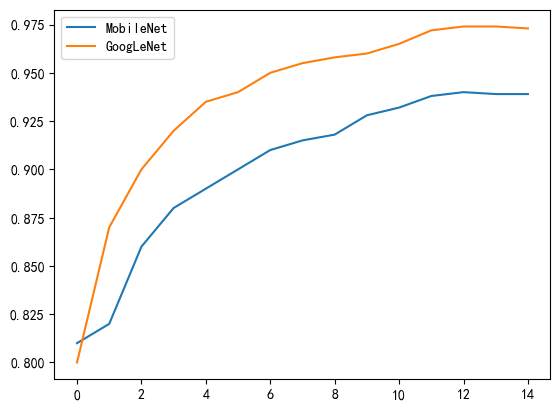

In [5]:
training_acc = [
    0.81, 0.82, 0.86, 0.88, 0.89, 0.90, 0.91, 0.915, 0.918, 0.928,
    0.932, 0.938, 0.94, 0.939, 0.939
]
training_acc1 = [
    0.80, 0.87, 0.90, 0.92, 0.935, 0.94, 0.95, 0.955, 0.958, 0.96,
    0.965, 0.972, 0.974, 0.974, 0.973
]
plt.plot(training_acc,label="MobileNet")
plt.plot(training_acc1,label="GoogLeNet")
plt.legend()
plt.show()

In [4]:
img_size = 114 #  图像尺寸维度
num_classes = 10 # 分类个数
learning_rate = 0.001 # 学习率
num_epochs = 50 # 循环周期
batch_size = 128 # 一个批次大小

train_data_dir =  r'data/训练数据/train/'
test_data_dir  =  r'data/训练数据/test/'

os.makedirs('data',exist_ok=True)
os.makedirs('model',exist_ok=True)

# 模型函数

In [5]:

def show_run_time(begin_time):
    """
    获取已使用时间
    begin_time = time.time()
    show_run_time(begin_time)
    """
    end_time = time.time()
    time_dif = end_time - begin_time
    seconds = time_dif/60
    seconds = round(seconds,1)
    print(f"花费时间{seconds}分钟")
    return time_dif



def load_weight2model(model, ckpt_path, map_location="cuda:0"):
    """
    加载模型权重
    """
    if not os.path.exists(ckpt_path):
        print("ckpt文件不存在，无法加载断点数据")
        return model, {"best_acc":-9999, "model_weight": None}
    ckpt = torch.load(ckpt_path, map_location=map_location)
    model.load_state_dict(ckpt["model_weight"])
    return model, ckpt

def train_one_epoch(model, dataloader, optimizer,loss_fn):
    
    """
    #训练一次epcoch模型
    计算loss还有acc
    """
    avg_loss = []
    pred_cls = [] # 预测类别
    real_cls = [] # 真实类别
    model.train()
    
    for batch_idx,(train_x,train_y) in enumerate(dataloader):
        train_x = train_x.to(device)
        real_cls.extend( train_y.numpy().tolist()  )
        train_y = train_y.to(device)
        
        #模型进行前向传播，得到结果
        pred = model(train_x)
        #从结果中计算损失
        loss = loss_fn(pred, train_y)
        #获得分类类别概率最大的类别ID
        cls_index = torch.argmax(pred, dim=1).cpu().numpy().tolist()
        pred_cls.extend(cls_index)
        #清空优化器保存的模型梯度，准备更细模型参数
        optimizer.zero_grad()
        #反向传播，计算梯度
        loss.backward()
        #优化器根据计算的梯度，更新模型的参数
        optimizer.step()
        avg_loss.append(loss.item())
    acc = accuracy_score(real_cls, pred_cls)
    avg_loss = np.array(avg_loss).mean()
    return acc, avg_loss

def eval_one_epoch(model, dataloader):
    """
    评价一次模型的效果，返回acc
    """
    pred_cls = []
    real_cls = []
    model.eval()
    for batch_idx,(train_x,train_y) in enumerate(dataloader):
        train_x = train_x.to(device)
        real_cls.extend( train_y.numpy().tolist()  )
        pred = model(train_x)
        cls_idx = torch.argmax(pred, dim=1).detach().cpu().numpy().tolist()
        pred_cls.extend(cls_idx)
    acc = accuracy_score(real_cls, pred_cls)
    f1  = f1_score(real_cls, pred_cls, average="macro")
    pre = precision_score(real_cls, pred_cls, average="macro")
    recall = recall_score(real_cls, pred_cls, average="macro")
    return acc, f1, pre,recall

114
112
56


# 数据集加载

In [6]:
train_transforms = transforms.Compose([
        transforms.CenterCrop( img_size ),#从中心开始裁剪，留下224x224的区域
        transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转 选择一个概率
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值，标准差（标准化操作）
    ])
test_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop( img_size ), # 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
# 训练集
train_dataset = datasets.ImageFolder(root = train_data_dir,
                               transform = train_transforms,
                              )
# 测试集
test_dataset = datasets.ImageFolder(root = test_data_dir ,
                               transform = test_transforms,
                              )
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
images,labels = iter(train_loader).next()
print('图像的尺寸',images.size())

index2label = train_dataset.classes
num_classes = len(index2label)
joblib.dump(index2label,'model/index2label.pkl')
# label2index
train_dataset.class_to_idx

图像的尺寸 torch.Size([128, 3, 114, 114])


{'Alfalfa': 0,
 'Asparagus': 1,
 'Blue_Vervain': 2,
 'Broadleaf_Plantain': 3,
 'Bull_Thistle': 4,
 'Cattail': 5,
 'Chickweed': 6,
 'Chicory': 7,
 'Cleavers': 8,
 'Coltsfoot': 9,
 'Common_Sow_Thistle': 10,
 'Common_Yarrow': 11,
 'Coneflower': 12,
 'Creeping_Charlie': 13,
 'Crimson_Clover': 14,
 'Curly_Dock': 15,
 'Daisy_Fleabane': 16,
 'Dandellion': 17,
 'Downy_Yellow_Violet': 18,
 'Elderberry': 19,
 'Evening_Primrose': 20,
 'Fern_Leaf_Yarrow': 21,
 'Field_Pennycress': 22,
 'Fireweed': 23,
 'Forget_Me_Not': 24,
 'Garlic_Mustard': 25,
 'Harebell': 26,
 'Henbit': 27,
 'Herb_Robert': 28,
 'Japanese_Knotweed': 29,
 'Joe_Pye_Weed': 30,
 'Knapweed': 31,
 'Kudzu': 32,
 'Lambs_Quarters': 33,
 'Mallow': 34,
 'Mayapple': 35,
 'Meadowsweet': 36,
 'Milk_Thistle': 37,
 'Mullein': 38,
 'New_England_Aster': 39,
 'Partridgeberry': 40,
 'Peppergrass': 41,
 'Pickerelweed': 42,
 'Pineapple_Weed': 43,
 'Prickly_Pear_Cactus': 44,
 'Purple_Deadnettle': 45,
 'Queen_Annes_Lace': 46,
 'Red_Clover': 47,
 'Sheep_

# 模型对比

In [9]:

def build_googlenet(num_classes):
    """
    构建 googlenet 模型
    """
    model = googlenet(pretrained=True)
    model.fc.out_features = num_classes
    return model


def build_mobilenet(num_classes):
    """
    构建 build_mobilenet 模型
    """
    model = mobilenet_v2(pretrained=True)
    model.classifier =  nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(1280,num_classes)
    )

    return model




def build_model(modelname,num_classes):
    """
    构建模型
    :return:
    """
    if modelname == "mobilenet_v2":
        model = build_mobilenet(num_classes)
   
    elif modelname == "googlenet":
        model = build_googlenet(num_classes)
 
    return model



# MobileNet调参训练

In [13]:
# 一个epoch 2 分钟
model_name = 'MobileNet'
from torch.optim.lr_scheduler import StepLR
begin_time = time.time()
num_epochs = 15
# 定义要调节的超参数空间
learning_rates = [0.001, 0.01,]
optimizers = {
    "Adam": optim.Adam,
}
results = {}
key2history = {}
# 网格搜索不同的超参数组合
for lr in learning_rates:
    for optimizer_name, optimizer_fn in optimizers.items():
        print(f"\nTraining with {optimizer_name} optimizer, lr={lr}")

        
        # 创建模型
        model = build_mobilenet(num_classes)
        model = model.to(device)

        # 选择优化器
        if optimizer_name == "SGD":
            optimizer = optimizer_fn(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = optimizer_fn(model.parameters(), lr=lr)

        # 损失函数
        criterion = nn.CrossEntropyLoss()

        # 学习率调度器
        scheduler = StepLR(optimizer, step_size=5, gamma=0.1) if optimizer_name != "Adam" else None
        acc_list = []
        loss_list = []
        # 训练模型
        for epoch in range(num_epochs):
            lasttime = time.time()
            acc, avg_loss = train_one_epoch(model,train_loader, optimizer, criterion)
            test_acc = eval_one_epoch(model, test_loader)[0]
            abstime = time.time()-lasttime
            print("epoch[{}/{}]\t train_loss={:.6f}\t train_acc={:.6f}\t test_acc={:.6f}\t time={:.1f}".format(
                epoch+1,num_epochs, avg_loss, acc, test_acc,abstime                                                              
                 ))
            acc_list.append(acc)
            loss_list.append(test_acc)
        
        acc = eval_one_epoch(model, test_loader)
        

        # 保存每个配置的结果
        key = f"{optimizer_name}-{lr}"
        results[key] = acc
        checkpoint = {}
        checkpoint["best_acc"] = acc
        checkpoint["model_weight"] = model.state_dict()
        if not os.path.exists("model"):
            os.mkdir('model')
        torch.save(checkpoint, f'model/{model_name}_{key}.pt')
        
        key2history[key] = {"acc":acc_list,"loss":loss_list}
print(show_run_time(begin_time))

#############
print(f"{model_name} 模型调参结果：")
sorted_result = sorted(results.items(),key=lambda x:x[1],reverse=True)
print(sorted_result)
print(f"{model_name} 最好模型：")
print( sorted_result[0] )


Training with Adam optimizer, lr=0.001
epoch[1/15]	 train_loss=0.865897	 train_acc=0.809102	 test_acc=0.825074	 time=72.2
epoch[2/15]	 train_loss=0.643544	 train_acc=0.838095	 test_acc=0.840110	 time=72.2
epoch[3/15]	 train_loss=0.544727	 train_acc=0.856839	 test_acc=0.860652	 time=72.5
epoch[4/15]	 train_loss=0.478612	 train_acc=0.868044	 test_acc=0.857899	 time=72.2
epoch[5/15]	 train_loss=0.435861	 train_acc=0.877124	 test_acc=0.871876	 time=72.4
epoch[6/15]	 train_loss=0.383783	 train_acc=0.888010	 test_acc=0.869970	 time=72.3
epoch[7/15]	 train_loss=0.368577	 train_acc=0.895391	 test_acc=0.869335	 time=72.5
epoch[8/15]	 train_loss=0.333073	 train_acc=0.903462	 test_acc=0.876535	 time=72.4
epoch[9/15]	 train_loss=0.303321	 train_acc=0.912596	 test_acc=0.871241	 time=72.2
epoch[10/15]	 train_loss=0.295059	 train_acc=0.914720	 test_acc=0.881618	 time=72.2
epoch[11/15]	 train_loss=0.243569	 train_acc=0.927517	 test_acc=0.874418	 time=72.3
epoch[12/15]	 train_loss=0.221427	 train_acc=

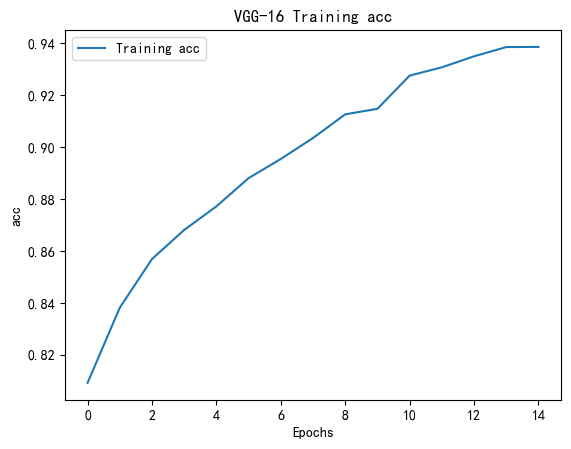

In [16]:
plt.plot(range(num_epochs), key2history[ sorted_result[0][0] ]['acc'], label='Training acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.title(f'{model_name} Training acc')
plt.legend()
plt.show()

# GoogLeNet模型调参训练

In [17]:
# 一个epoch 2 分钟
model_name = 'GoogLeNet'
from torch.optim.lr_scheduler import StepLR
begin_time = time.time()
num_epochs = 15
# 定义要调节的超参数空间
learning_rates = [0.001, 0.01,]
optimizers = {
    "Adam": optim.Adam,
}
results = {}
key2history = {}
# 网格搜索不同的超参数组合
for lr in learning_rates:
    for optimizer_name, optimizer_fn in optimizers.items():
        print(f"\nTraining with {optimizer_name} optimizer, lr={lr}")

        
        # 创建模型
        model = build_googlenet(num_classes)
        model = model.to(device)

        # 选择优化器
        if optimizer_name == "SGD":
            optimizer = optimizer_fn(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = optimizer_fn(model.parameters(), lr=lr)

        # 损失函数
        criterion = nn.CrossEntropyLoss()

        # 学习率调度器
        scheduler = StepLR(optimizer, step_size=5, gamma=0.1) if optimizer_name != "Adam" else None
        acc_list = []
        loss_list = []
        # 训练模型
        for epoch in range(num_epochs):
            lasttime = time.time()
            acc, avg_loss = train_one_epoch(model,train_loader, optimizer, criterion)
            test_acc = eval_one_epoch(model, test_loader)[0]
            abstime = time.time()-lasttime
            print("epoch[{}/{}]\t train_loss={:.6f}\t train_acc={:.6f}\t test_acc={:.6f}\t time={:.1f}".format(
                epoch+1,num_epochs, avg_loss, acc, test_acc,abstime                                                              
                 ))
            acc_list.append(acc)
            loss_list.append(test_acc)
        
        acc = eval_one_epoch(model, test_loader)
        

        # 保存每个配置的结果
        key = f"{optimizer_name}-{lr}"
        results[key] = acc
        checkpoint = {}
        checkpoint["best_acc"] = acc
        checkpoint["model_weight"] = model.state_dict()
        if not os.path.exists("model"):
            os.mkdir('model')
        torch.save(checkpoint, f'model/{model_name}_{key}.pt')
        
        key2history[key] = {"acc":acc_list,"loss":loss_list}
print(show_run_time(begin_time))

#############
print(f"{model_name} 模型调参结果：")
sorted_result = sorted(results.items(),key=lambda x:x[1],reverse=True)
print(sorted_result)
print(f"{model_name} 最好模型：")
print( sorted_result[0] )


Training with Adam optimizer, lr=0.001
epoch[1/15]	 train_loss=1.039210	 train_acc=0.802092	 test_acc=0.844346	 time=69.5
epoch[2/15]	 train_loss=0.543644	 train_acc=0.862946	 test_acc=0.866794	 time=69.3
epoch[3/15]	 train_loss=0.431766	 train_acc=0.886629	 test_acc=0.877806	 time=69.4
epoch[4/15]	 train_loss=0.352271	 train_acc=0.904418	 test_acc=0.845828	 time=69.8
epoch[5/15]	 train_loss=0.300355	 train_acc=0.915941	 test_acc=0.865523	 time=69.5
epoch[6/15]	 train_loss=0.243764	 train_acc=0.927942	 test_acc=0.883100	 time=69.5
epoch[7/15]	 train_loss=0.208265	 train_acc=0.937819	 test_acc=0.857687	 time=69.5
epoch[8/15]	 train_loss=0.203765	 train_acc=0.941748	 test_acc=0.884795	 time=69.4
epoch[9/15]	 train_loss=0.166366	 train_acc=0.951094	 test_acc=0.891783	 time=69.2
epoch[10/15]	 train_loss=0.149468	 train_acc=0.956829	 test_acc=0.877806	 time=69.3
epoch[11/15]	 train_loss=0.142582	 train_acc=0.956723	 test_acc=0.891360	 time=69.3
epoch[12/15]	 train_loss=0.108763	 train_acc=

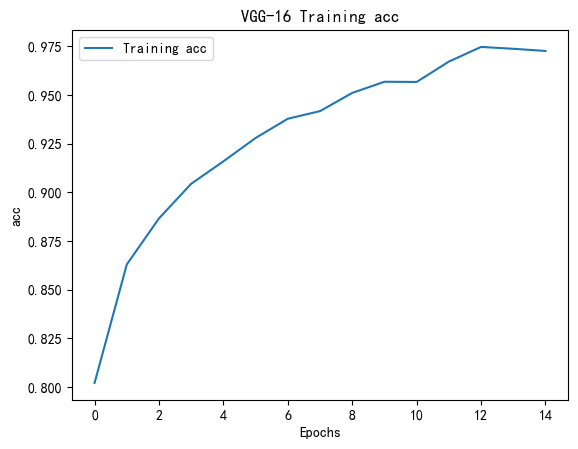

In [18]:
plt.plot(range(num_epochs), key2history[ sorted_result[0][0] ]['acc'], label='Training acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.title('VGG-16 Training acc')
plt.legend()
plt.show()